In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from IPython.utils.openpy import source_to_unicode

In [2]:
print(os.getcwd())

/Users/semikzr/PycharmProjects/movie-recommender-system/notebooks


In [37]:
df = pd.read_csv('../data/movie.csv')
df.head()
df_rating = pd.read_csv('../data/rating.csv')

In [43]:
df.columns

Index(['movieId', 'title', 'genres'], dtype='str')

In [31]:
df.genres.value_counts()

genres
Drama                                        4520
Comedy                                       2294
Documentary                                  1942
Comedy|Drama                                 1264
Drama|Romance                                1075
                                             ... 
Adventure|Children|Drama|Sci-Fi                 1
Children|Documentary|Drama                      1
Action|Adventure|Animation|Fantasy|Horror       1
Animation|Children|Comedy|Fantasy|Sci-Fi        1
Animation|Children|Comedy|Western               1
Name: count, Length: 1342, dtype: int64

In [45]:
df_rating.columns

Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='str')

In [47]:
df_rating.rating.value_counts()

rating
4.0    5561926
3.0    4291193
5.0    2898660
3.5    2200156
4.5    1534824
2.0    1430997
2.5     883398
1.0     680732
1.5     279252
0.5     239125
Name: count, dtype: int64

In [53]:
avg_rating = df_rating.groupby('movieId')['rating'].mean().reset_index()


In [84]:
avg_rating.info()

<class 'pandas.DataFrame'>
RangeIndex: 26744 entries, 0 to 26743
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   movieId  26744 non-null  int64  
 1   rating   26744 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 418.0 KB


In [54]:
merged_df = pd.merge(df, df_rating, on='movieId')
merged_df.head()
avg_merged_df = pd.merge(df , avg_rating, on='movieId')

In [49]:
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000263 entries, 0 to 20000262
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   movieId    int64  
 1   title      str    
 2   genres     str    
 3   userId     int64  
 4   rating     float64
 5   timestamp  str    
dtypes: float64(1), int64(2), str(3)
memory usage: 915.5 MB


In [55]:
avg_merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26744 entries, 0 to 26743
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   movieId  26744 non-null  int64  
 1   title    26744 non-null  str    
 2   genres   26744 non-null  str    
 3   rating   26744 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 835.9 KB


### GENRE SCORES ###

In [63]:
genre_df = avg_merged_df.copy()

genre_df['genres'] = genre_df['genres'].apply(lambda x: x.split('|')) # split the genres into a list

genre_df = genre_df.explode("genres")

genre_scores = genre_df.groupby('genres')['rating'].mean().sort_values(ascending=False)

# sort the genres by average rating


In [66]:
genre_count = genre_df["genres"].value_counts()
print(genre_count)

genres
Drama                 13062
Comedy                 8232
Thriller               4129
Romance                4029
Action                 3466
Crime                  2889
Horror                 2590
Documentary            2391
Adventure              2287
Sci-Fi                 1720
Mystery                1489
Fantasy                1398
War                    1173
Children               1118
Musical                1016
Animation              1015
Western                 656
Film-Noir               322
(no genres listed)      242
IMAX                    195
Name: count, dtype: int64


<Axes: title={'center': 'Average Rating by Genre'}, ylabel='genres'>

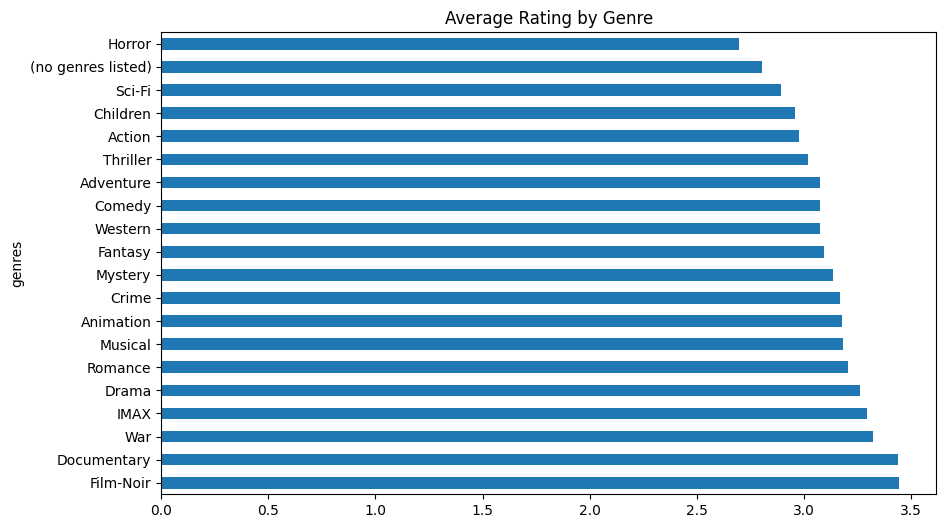

In [76]:
genre_scores.plot(kind="barh", figsize=(10,6), title="Average Rating by Genre")

<Axes: title={'center': 'Average Rating by Genre'}, xlabel='rating', ylabel='genres'>

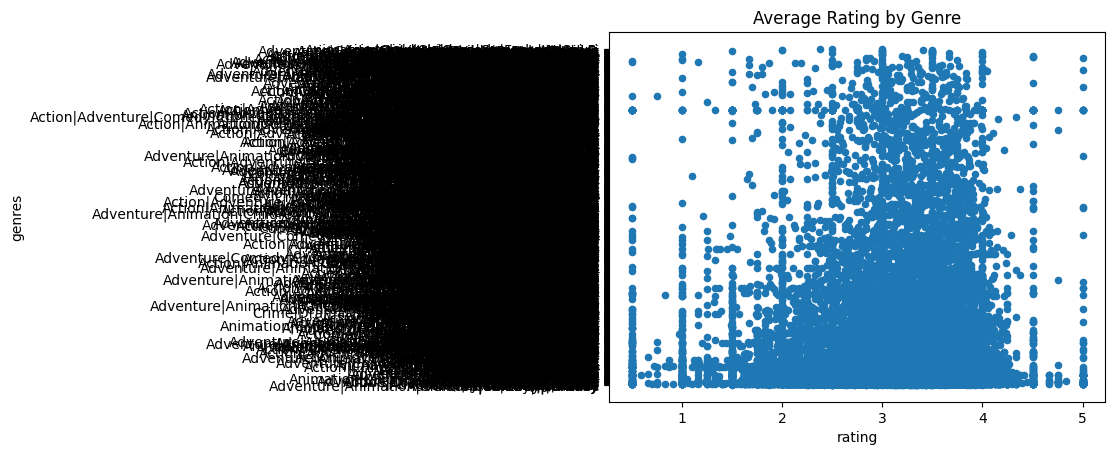

In [83]:
avg_merged_df.plot(kind="scatter", x="rating", y="genres", title="Average Rating by Genre")

 # Notes
  - Create new df for find rating count for all movie
  - Save the filtered movie feature data frame as csv file to data/processed

In [85]:
avg_merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26744 entries, 0 to 26743
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   movieId  26744 non-null  int64  
 1   title    26744 non-null  str    
 2   genres   26744 non-null  str    
 3   rating   26744 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 835.9 KB


In [89]:
count_df = df_rating.groupby("movieId").size().reset_index(name="rating_count")
count_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26744 entries, 0 to 26743
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   movieId       26744 non-null  int64
 1   rating_count  26744 non-null  int64
dtypes: int64(2)
memory usage: 418.0 KB


In [97]:
popularity_df = avg_merged_df.merge(count_df,on="movieId")
popularity_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26744 entries, 0 to 26743
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   movieId       26744 non-null  int64  
 1   title         26744 non-null  str    
 2   genres        26744 non-null  str    
 3   rating        26744 non-null  float64
 4   rating_count  26744 non-null  int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 1.0 MB


In [123]:
filtered_popularity_df = popularity_df[popularity_df['rating_count'] >= 60]

In [124]:
filtered_popularity_df.info()

<class 'pandas.DataFrame'>
Index: 10000 entries, 0 to 25693
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   movieId       10000 non-null  int64  
 1   title         10000 non-null  str    
 2   genres        10000 non-null  str    
 3   rating        10000 non-null  float64
 4   rating_count  10000 non-null  int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 468.8 KB


<Axes: title={'center': 'Rating vs Rating Count'}, xlabel='rating', ylabel='rating_count'>

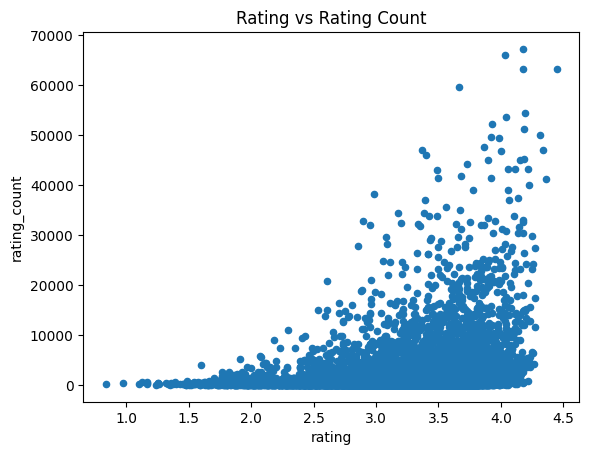

In [125]:
filtered_popularity_df.plot(kind="scatter", x="rating", y="rating_count", title="Rating vs Rating Count")

<Axes: title={'center': 'Rating vs Rating Count'}, xlabel='rating', ylabel='rating_count'>

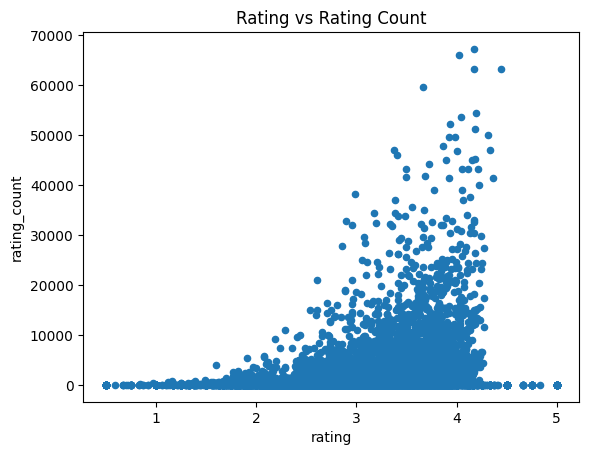

In [121]:
popularity_df.plot(kind="scatter", x="rating", y="rating_count", title="Rating vs Rating Count")

In [126]:
filtered_popularity_df.to_csv("../data/processed/movie_features.csv", index=False)